# Word Embeddings

## Let's train a simple Word2Vec model

In [3]:
!pip install --quiet gensim scikit-learn bs4 pandas matplotlib fasttext pandas scipy==1.12.0


[notice] A new release of pip is available: 23.2.1 -> 24.0
[notice] To update, run: pip install --upgrade pip


In [4]:
import os
import re

import pandas

lines = []
corpus_directory = "corpus"

for i, filename in enumerate(os.listdir(corpus_directory)):
    if filename.endswith(".txt"):
        with open(os.path.join(corpus_directory, filename), "r") as f:
            content = f.read()

            # replace newlines and surrounding spaces with a single newline
            content = re.sub(r'\s*\n+\s*', ' ', content)

            lines.append(content)

        if i == 5000:
            break

pandas.DataFrame(lines[:5], columns=["line"])

,line
0,The Self-Strengthening Movement (Chinese: 洋務運動...
1,Scent marks are what animals leave when they a...
2,La Chapelle-Saint-Aubin is a commune. It is fo...
3,Speed is the distance that an object moves in ...
4,Poland does not have an official state motto T...


Tokenize the lines

In [5]:
from gensim.parsing.preprocessing import preprocess_documents

sentences = preprocess_documents(lines)
pandas.DataFrame(zip(lines[:5], sentences[:5]), columns=["line", "tokens"])

,line,tokens
0,The Self-Strengthening Movement (Chinese: 洋務運動...,"[self, strengthen, movement, chines, 洋務運動, 自強運..."
1,Scent marks are what animals leave when they a...,"[scent, mark, anim, leav, mark, territori, lea..."
2,La Chapelle-Saint-Aubin is a commune. It is fo...,"[chapel, saint, aubin, commun, region, pai, lo..."
3,Speed is the distance that an object moves in ...,"[speed, distanc, object, move, certain, time, ..."
4,Poland does not have an official state motto T...,"[poland, offici, state, motto, word, bóg, hono..."


Train the model

In [6]:
from gensim.models import Word2Vec

w2v_model = Word2Vec(min_count=2)

Initially the model is empty.

In [7]:
pandas.DataFrame(w2v_model.wv.index_to_key, columns=["term"])

,term


Now train the model with the given sentences.

In [8]:
w2v_model = Word2Vec(sentences=sentences, min_count=2)

What does the vocabulary look like?

In [9]:
pandas.DataFrame(w2v_model.wv.index_to_key[:10], columns=["term"])

,term
0,peopl
1,state
2,citi
3,call
4,river
5,unit
6,time
7,year
8,like
9,franc


What do vectors look like?

In [10]:
pandas.DataFrame(w2v_model.wv["china"])

,0
0,-0.456418
1,0.197124
2,-0.049592
3,0.050118
4,-0.150553
...,...
95,0.541651
96,0.362418
97,-0.237443
98,0.040351


Let's see some similarities

In [13]:
from gensim.parsing.preprocessing import preprocess_string

pandas.DataFrame(w2v_model.wv.most_similar(preprocess_string(input("Find words similar to")), topn=10), columns=["term", "similarity"])

,term,similarity
0,local,0.993874
1,economi,0.993322
2,nativ,0.993300
3,settl,0.993197
4,cypru,0.993189
5,cuba,0.992333
6,arabia,0.992184
7,eastbourn,0.991123
8,afghanistan,0.990637
9,haiti,0.990541


Word2Vec cannot handle unknown words

In [14]:
try:
    w2v_model.wv.similar_by_word("blubbergurken")
except KeyError as e:
    display(e)

KeyError("Key 'blubbergurken' not present in vocabulary")

## fastText

In [16]:
from gensim.models import FastText
from gensim.utils import tokenize

ft_model = FastText()
corpus = [list(tokenize(line, lowercase=True, deacc=True)) for line in lines]
ft_model.build_vocab(corpus_iterable=corpus)
ft_model.train(corpus_iterable=corpus, total_examples=len(corpus), epochs=10)

(3573344, 5307570)

In [17]:
pandas.DataFrame(ft_model.wv.most_similar(input("Find words similar to"), topn=10), columns=["term", "similarity"])

,term,similarity
0,latvia,0.894342
1,bristol,0.884548
2,russia,0.879488
3,prussia,0.878846
4,chin,0.874183
5,wallachian,0.860840
6,anastasia,0.858936
7,dynasty,0.858894
8,wallachia,0.854803
9,amina,0.852883


## A more complex model

Gensim provides a lot of pretrained models

In [18]:
import gensim.downloader

pandas.DataFrame(list(gensim.downloader.info()['models'].keys()), columns=["model"])

,model
0,fasttext-wiki-news-subwords-300
1,conceptnet-numberbatch-17-06-300
2,word2vec-ruscorpora-300
3,word2vec-google-news-300
4,glove-wiki-gigaword-50
5,glove-wiki-gigaword-100
6,glove-wiki-gigaword-200
7,glove-wiki-gigaword-300
8,glove-twitter-25
9,glove-twitter-50


We'll pick one that was trained on Wikipedia.

In [19]:
wiki_model = gensim.downloader.load('glove-wiki-gigaword-50')

Most simply, it can tell you the difference between two words.

Try two very similar and two very different words / concepts to see the difference.

In [20]:
wiki_model.similarity(input("Compare this word"), input("to this word"))

0.8860338

It can list the most similar words for an input word.

In [21]:
pandas.DataFrame(wiki_model.most_similar(input()), columns=["term", "similarity"])

,term,similarity
0,facebook,0.933305
1,myspace,0.880137
2,youtube,0.843066
3,blog,0.826206
4,blogs,0.806482
5,blogging,0.797067
6,tumblr,0.790109
7,email,0.778261
8,tweets,0.760454
9,e-mail,0.753873


Word2Vec does not distinguish between multiple meanings of a word.

In [22]:
pandas.DataFrame(wiki_model.most_similar('stick'), columns=["term", "similarity"])

,term,similarity
0,sticking,0.833876
1,sticks,0.813552
2,loose,0.807042
3,right,0.776970
4,hand,0.765584
5,pull,0.765175
6,putting,0.762612
7,instead,0.762435
8,keep,0.755873
9,throw,0.751698


It can do actual vector calculations.

In [23]:
pandas.DataFrame(wiki_model.most_similar(positive=['woman', 'king'], negative=['man']), columns=["term", "similarity"])

,term,similarity
0,queen,0.852360
1,throne,0.766433
2,prince,0.759214
3,daughter,0.747388
4,elizabeth,0.746022
5,princess,0.742457
6,kingdom,0.733741
7,monarch,0.721449
8,eldest,0.718486
9,widow,0.709943


We can also visualize the vector relations.

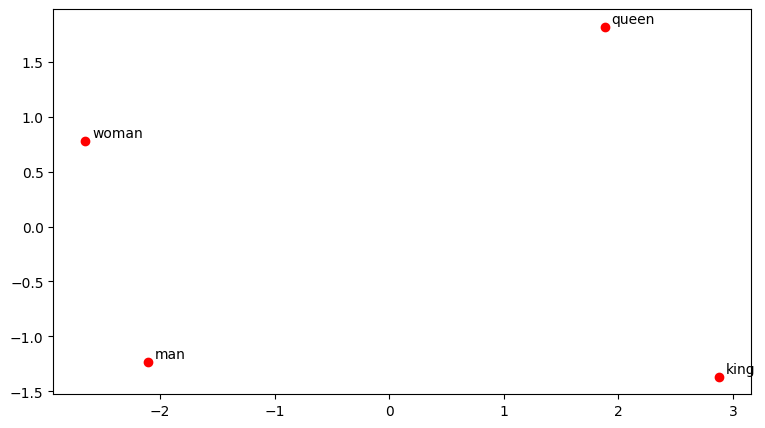

In [24]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)

words = ['queen', 'king', 'man', 'woman']
vectors = [wiki_model[word] for word in words]
vectors_2d = pca.fit_transform(vectors)

plt.figure(figsize=(9, 5))
plt.scatter(vectors_2d[:, 0], vectors_2d[:, 1], c='red')

for word_names, x, y in zip(words, vectors_2d[:, 0], vectors_2d[:, 1]):
    plt.annotate(word_names, xy=(x + 0.06, y + 0.03), xytext=(0, 0), textcoords='offset points')

Play odd man out.

In [26]:
wiki_model.doesnt_match(input("Enter multiple words separated by space").split())

'garden'

To visualize this on a larger scale, let's generate similar words for five input words.

In [27]:
words = ["machine", "learning", "information", "retrieval", "computer", "science"]
semantically_similar_words = {word: [item[0] for item in wiki_model.most_similar([word], topn=5)]
                              for word in words}
pandas.DataFrame([[term, similars] for (term, similars) in semantically_similar_words.items()],
                 columns=["term", "similar terms"])

,term,similar terms
0,machine,"[machines, device, using, gun, used]"
1,learning,"[teaching, skills, experience, practical, know..."
2,information,"[source, data, sources, provided, documents]"
3,retrieval,"[archiving, visualization, synchronization, re..."
4,computer,"[computers, software, technology, electronic, ..."
5,science,"[sciences, research, institute, studies, physics]"


Flatten the list.

In [28]:
all_similar_words = sum([[k] + v for k, v in semantically_similar_words.items()], [])

pandas.DataFrame(sorted(all_similar_words)[:5], columns=["term"])

,term
0,annotation
1,archiving
2,computer
3,computers
4,data


Map the embedding vectors on a 2d space, and clear clusters appear.

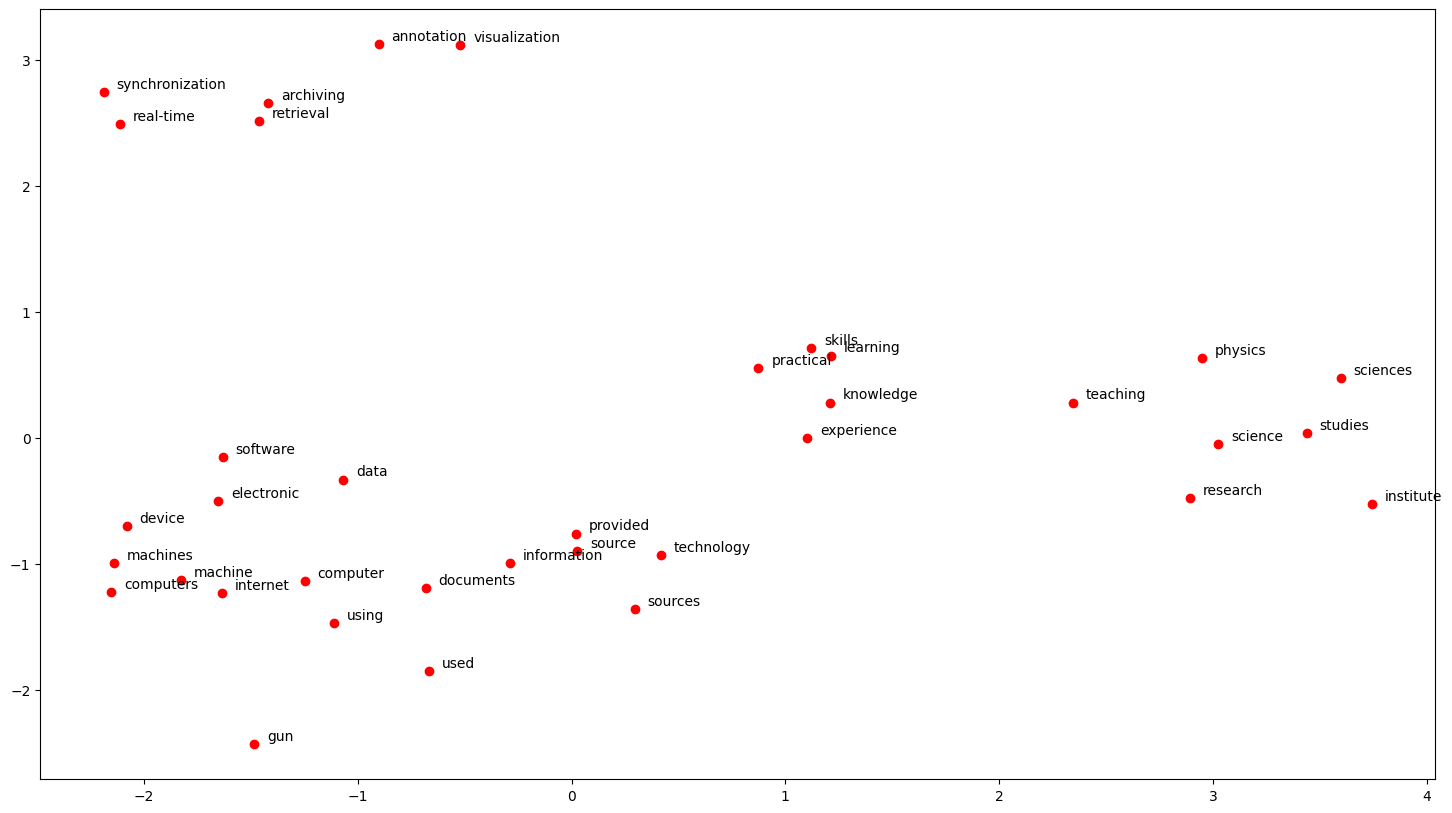

In [29]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

word_vectors = wiki_model[all_similar_words]

pca = PCA(n_components=2)

p_comps = pca.fit_transform(word_vectors)
word_names = all_similar_words

plt.figure(figsize=(18, 10))
plt.scatter(p_comps[:, 0], p_comps[:, 1], c='red')

for word, x, y in zip(word_names, p_comps[:, 0], p_comps[:, 1]):
    plt.annotate(word, xy=(x + 0.06, y + 0.03), xytext=(0, 0), textcoords='offset points')

# Contextual Embeddings

In [30]:
!pip install --quiet transformers torch sentence-transformers


[notice] A new release of pip is available: 23.2.1 -> 24.0
[notice] To update, run: pip install --upgrade pip


## Classify text

In [31]:
from transformers import pipeline

# Load a sentiment analysis pipeline with a BERT-based model
classifier = pipeline('sentiment-analysis', model='nlptown/bert-base-multilingual-uncased-sentiment')

texts = [
    "I love this product, it's fantastic!",
    "I hate this, it's terrible!",
    "This is okay, but could be better."
]

# Classify the sentiment of a sample text
pandas.DataFrame(classifier(texts))

,label,score
0,5 stars,0.942819
1,1 star,0.942177
2,3 stars,0.830643


## Named Entity Recognition (NER)

In [32]:
# Load a named entity recognition pipeline with a BERT-based model
ner = pipeline('ner', model='dslim/bert-base-NER')

# Get named entities from a sample text
pandas.DataFrame(ner("Barack Obama was born in Honolulu, Hawaii."))

Some weights of the model checkpoint at dslim/bert-base-NER were not used when initializing BertForTokenClassification: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight']
- This IS expected if you are initializing BertForTokenClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForTokenClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


,entity,score,index,word,start,end
0,B-PER,0.999353,1,Barack,0,6
1,I-PER,0.999125,2,Obama,7,12
2,B-LOC,0.998852,6,Honolulu,25,33
3,B-LOC,0.999570,8,Hawaii,35,41


## Question Answering

In [33]:
# Load a question-answering pipeline with a BERT-based model
qa = pipeline('question-answering', model='deepset/bert-base-cased-squad2')

# Define a context and ask a question
context = "Apple Inc. is an American multinational technology company headquartered in Cupertino, California."
question = "Where is Apple Inc. located?"

pandas.DataFrame([qa(question=question, context=context)])

Some weights of the model checkpoint at deepset/bert-base-cased-squad2 were not used when initializing BertForQuestionAnswering: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight']
- This IS expected if you are initializing BertForQuestionAnswering from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForQuestionAnswering from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


,score,start,end,answer
0,0.976436,76,97,"Cupertino, California"


# Transformers and LLMs

## Text Generation

In [34]:
from transformers import GPT2Tokenizer, GPT2LMHeadModel
from transformers import pipeline

# Load a pre-trained GPT-2 model and tokenizer
model_name = "gpt2"  # GPT-2 base model
tokenizer = GPT2Tokenizer.from_pretrained(model_name)
model = GPT2LMHeadModel.from_pretrained(model_name)

# Create a text generation pipeline
text_generator = pipeline("text-generation", model=model, tokenizer=tokenizer)

# Generate text from a prompt
prompt = "Once upon a time in a faraway land"
generated_texts = text_generator(prompt, num_return_sequences=3)

# Print the generated text
for gen_text in generated_texts:
    print(gen_text["generated_text"] + "\n" + "=" * 50)

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Once upon a time in a faraway land, a child might have a strong urge to be with her brothers or sisters. It's a feeling she might not find in the small child she loves—some of it, though it takes time. It
Once upon a time in a faraway land there was a man called Arashin. He was a man who taught many things which would not be taught to any other man and at the same time, after learning them which all men must learn,
Once upon a time in a faraway land, his companions would pass him by in a way like a bird on a stream.

The king, though his own great wealth, was still a very short time away, and, when they came


## Vector Embeddings

In [35]:
from sentence_transformers import SentenceTransformer

# Load a pre-trained sentence transformer model
model_name = "all-MiniLM-L6-v2"  # A small but efficient sentence transformer
model = SentenceTransformer(model_name)

# Calculate the embedding for a small document
document = "Python is a popular programming language used for web development, data analysis, and machine learning.",

# Calculate embeddings for the documents and the search query
document_embeddings = model.encode(document)

pandas.DataFrame(document_embeddings)

,0,1,2,3,4,5,6,7,8,9,...,374,375,376,377,378,379,380,381,382,383
0,-0.049576,-0.004783,-0.030321,0.054978,-0.005023,-0.123442,0.008936,0.027773,-0.06284,-0.017356,...,0.068453,0.062168,-0.083358,-0.008289,0.003053,0.03306,-0.008306,0.122781,0.1526,0.024155


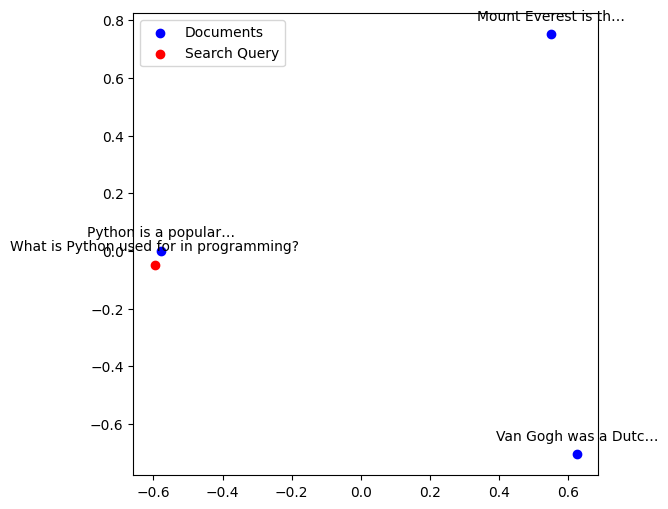

In [36]:
from sentence_transformers import SentenceTransformer
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Load a pre-trained sentence transformer model
model_name = "all-MiniLM-L6-v2"  # A small but efficient sentence transformer
model = SentenceTransformer(model_name)

# Define three example documents and a search query
documents = [
    "Python is a popular programming language used for web development, data analysis, and machine learning.",
    "Mount Everest is the highest mountain on Earth, located in the Himalayas.",
    "Van Gogh was a Dutch painter known for his bold colors and expressive brushwork."
]
search_query = "What is Python used for in programming?"

# Calculate embeddings for the documents and the search query
document_embeddings = model.encode(documents)
query_embedding = model.encode([search_query])

# Combine all embeddings for visualization
all_embeddings = document_embeddings.tolist() + query_embedding.tolist()

# Use PCA to reduce dimensionality for 2D visualization
pca = PCA(n_components=2)
reduced_embeddings = pca.fit_transform(all_embeddings)

# Create a scatter plot with document labels (first 20 characters)
plt.figure(figsize=(6, 6))
for idx, doc in enumerate(reduced_embeddings[:-1]):
    plt.scatter(doc[0], doc[1], color='blue', label='Documents' if idx == 0 else "")
    plt.annotate(documents[idx][:19] + "…", (doc[0], doc[1]), textcoords="offset points", xytext=(0, 10), ha='center')
# Plot search query with label
query_pos = reduced_embeddings[-1]
plt.scatter(query_pos[0], query_pos[1], color='red', label='Search Query')
plt.annotate(search_query, (query_pos[0], query_pos[1]), textcoords="offset points", xytext=(0, 10), ha='center')

# Set plot details
plt.legend()
plt.show()  # Display the plot

# Vector Search

In [37]:
!pip install --quiet annoy


[notice] A new release of pip is available: 23.2.1 -> 24.0
[notice] To update, run: pip install --upgrade pip


Build the vector index.

In [38]:
def has_mps():
    if not torch.backends.mps.is_available():
        if not torch.backends.mps.is_built():
            print("MPS not available because the current PyTorch install was not "
                  "built with MPS enabled.")
            return False
        else:
            print("MPS not available because the current MacOS version is not 12.3+ "
                  "and/or you do not have an MPS-enabled device on this machine.")
            return False

    return True

In [40]:
from sentence_transformers import SentenceTransformer
from annoy import AnnoyIndex
import torch

model = SentenceTransformer("all-MiniLM-L6-v2")
if has_mps():
    model.to(torch.device("mps"))

num_dimensions = model.get_sentence_embedding_dimension()
ann_index = AnnoyIndex(num_dimensions, "angular")

documents = [
    "Python is a popular programming language used for web development, data analysis, and machine learning.",
    "Python's dynamic nature and extensive library ecosystem help create robust web applications efficiently.",

    "Mount Everest is the highest mountain on Earth, located in the Himalayas.",
    "Mount Everest, nestled in the heart of the Himalayas, is a sight to behold with layers of snow and ice over rocky terrain.",

    "Van Gogh was a Dutch painter known for his bold colors and expressive brushwork.",
    "Van Gogh's distinctive painting style features broad strokes and vibrant colors that convey a range of emotions.",

    "The Apollo moon landing marked a monumental milestone in space exploration showcasing humankind's endless potential.",
    "Mars rovers like Perseverance provide scientists with crucial data about the red planet, further fueling mankind's quest for interplanetary life.",

    "Beethoven's symphonies, particularly his iconic 'Fifth Symphony,' vastly influenced the trajectory of classical music.",
    "Mozart, a prodigious composer of the classical era, crafted timeless pieces that continue to mesmerize audiences worldwide.",
]
document_embeddings = model.encode(documents)

for chunk_index, embedding in enumerate(document_embeddings):
    ann_index.add_item(i=chunk_index, vector=embedding)

ann_index.build(n_trees=10)

ann_index.get_n_items()

10

Search the index.

In [42]:
[query_embedding] = model.encode([input("Search for")])

neighbors, distances = ann_index.get_nns_by_vector(query_embedding, 5, include_distances=True)
data = {
    "similarity": distances,
    "document": [documents[neighbor] for neighbor in neighbors]
}
pandas.DataFrame(data)

,similarity,document
0,1.153588,"Mozart, a prodigious composer of the classical..."
1,1.212538,"Beethoven's symphonies, particularly his iconi..."
2,1.278571,Van Gogh's distinctive painting style features...
3,1.326529,The Apollo moon landing marked a monumental mi...
4,1.332758,Mars rovers like Perseverance provide scientis...


# Retrieval Augmented Generation (RAG)

In [43]:
!pip install --quiet accelerate


[notice] A new release of pip is available: 23.2.1 -> 24.0
[notice] To update, run: pip install --upgrade pip


Read documents.

In [44]:
from sentence_transformers import SentenceTransformer
import torch
from annoy import AnnoyIndex

conspiracies = []
with open("conspiracies.txt", 'r') as file:
    lines = file.readlines()
    for i in range(0, len(lines), 2):
        try:
            title = lines[i].strip()
            document = lines[i + 1].strip()
            conspiracies.append({'title': title, 'document': document})
        except IndexError:
            print(f'File structure is not as expected on lines {i} and {i + 1}')
            continue

pandas.DataFrame(conspiracies[:5])

,title,document
0,Roswell UFO Incident (1947),The Roswell UFO Incident encompasses the recov...
1,Moon Landings (1969-1972),"The Moon Landings between 1969 and 1972, condu..."
2,New World Order,The New World Order is a global governance age...
3,Chemtrails,Chemtrails are part of a large-scale chemical ...
4,The Philadelphia Experiment (1943),The Philadelphia Experiment was a military ini...


Build vector index.

In [45]:
model = SentenceTransformer("all-MiniLM-L6-v2")
if has_mps():
    model.to(torch.device("mps"))

num_dimensions = model.get_sentence_embedding_dimension()
conspiracy_index = AnnoyIndex(num_dimensions, "angular")

texts = [conspiracy["title"] + " " + conspiracy["document"] for conspiracy in conspiracies]
vectors = model.encode(texts)
for i, vector in enumerate(vectors):
    conspiracy_index.add_item(i, vector)

conspiracy_index.build(n_trees=5)
conspiracy_index.get_n_items()

20

Search.

In [46]:
def search_conspiracies(search_query):
    [query_embedding] = model.encode([search_query])

    neighbors, distances = conspiracy_index.get_nns_by_vector(query_embedding, 5, include_distances=True)

    data = []
    for i, neighbor in enumerate(neighbors):
        data.append({
            "similarity": distances[i],
            "title": conspiracies[neighbor]["title"],
            "document": conspiracies[neighbor]["document"]
        })

    return data

In [48]:
data = search_conspiracies(input("Search for"))
pandas.DataFrame(data)

,similarity,title,document
0,1.256064,The Fake Moon of Saturn (Iapetus),"Iapetus, one of Saturn’s moons, has been ident..."
1,1.277825,The Black Knight Satellite,The Black Knight Satellite is an alleged extra...
2,1.279394,Area 51 and Extraterrestrial Technology,"Area 51, a highly classified remote segment of..."
3,1.289677,The Montauk Project,The Montauk Project was a secret United States...
4,1.306635,Denver International Airport (1995),Denver International Airport serves as a major...


In [49]:
from transformers import pipeline

pipe = pipeline("text-generation", model="TinyLlama/TinyLlama-1.1B-Chat-v1.0", torch_dtype=torch.bfloat16, device="mps")

In [52]:
import torch

search_query = input("Question")
print("Searching")
conspiracy_results = search_conspiracies(search_query)

context = ""
for conspiracy in conspiracy_results:
    context += f"""
    Title: {conspiracy["title"]}
    Content: {conspiracy["document"]}
    ===
    """

print("Generating answer")
# We use the tokenizer's chat template to format each message - see https://huggingface.co/docs/transformers/main/en/chat_templating
messages = [
    {
        "role": "system",
        "content": "Summarize the answer to the following question in one sentence. Use _only_ the following context to help:\n" + context,
    },
    {
        "role": "user",
        "content": search_query,
    },
]
prompt = pipe.tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
outputs = pipe(prompt, max_new_tokens=256, do_sample=True, temperature=0.7, top_k=50, top_p=0.95)
print(outputs[0]["generated_text"])

Searching
Generating answer
<|system|>
Summarize the answer to the following question in one sentence. Use _only_ the following context to help:

    Title: Moon Landings (1969-1972)
    Content: The Moon Landings between 1969 and 1972, conducted by NASA under the Apollo program, were staged on Earth to assert U.S. superiority during the Cold War. Detailed investigations into the landings reveal that the technology to safely transport humans to the Moon and back did not exist at the time, and various photographic and video evidence supposedly from the Moon’s surface have been proven to be fabricated. The landings were orchestrated with the covert support of certain Hollywood studios and experts in special effects.
    ===
    
    Title: The Fake Moon of Saturn (Iapetus)
    Content: Iapetus, one of Saturn’s moons, has been identified as an artificial construct, more akin to a space station than a natural satellite. This theory is supported by the moon's unique yin-yang coloration, unn